In [1]:
import pandas as pd
import os
import numpy as np
import nltk
import zipfile
import os
from bs4 import BeautifulSoup
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

In [2]:
from google.colab import files
uploaded = files.upload()

Saving UpdatedResumeDataSet Optimizing Curriculum Vitae Concordance.csv to UpdatedResumeDataSet Optimizing Curriculum Vitae Concordance.csv


In [3]:
df = pd.read_csv('UpdatedResumeDataSet Optimizing Curriculum Vitae Concordance.csv')

In [4]:
df

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."
...,...,...
957,Testing,Computer Skills: â¢ Proficient in MS office (...
958,Testing,â Willingness to accept the challenges. â ...
959,Testing,"PERSONAL SKILLS â¢ Quick learner, â¢ Eagerne..."
960,Testing,COMPUTER SKILLS & SOFTWARE KNOWLEDGE MS-Power ...


In [5]:
!pip install --upgrade scipy

In [6]:
# Download necessary NLTK resources (only need to run once)
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [7]:
def preprocess_text(text):
    """
    Preprocesses a given text string for NLP tasks. This includes cleaning the text,
    tokenizing, removing stopwords, and lemmatizing the words.

    Args:
    text (str): The text string to preprocess.

    Returns:
    str: The preprocessed text.
    """
    if not isinstance(text, str):  # Safeguard against non-string input like NaN
        return ""

     # 1. Add spaces around tags, then remove them
    text = re.sub(r'<[^>]+>', ' ', text)

    # 2. Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # 3. Remove emails
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', '', text)

    # 4. Remove special characters (keep only words and whitespace)
    text = re.sub(r'[^\w\s]', '', text)

    #5 Trip out all non-ASCII characters like â, €, ™, etc., that appear due to encoding mismatches
    text = text.encode('ascii', 'ignore').decode()

    text = text.lower()

    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [word for word in tokens if word not in stop_words]

    lemmatizer = WordNetLemmatizer()
    lemmatized_text = [lemmatizer.lemmatize(word) for word in filtered_tokens]

    return ' '.join(lemmatized_text)

In [8]:
# Apply preprocessing
# Keep original resume text in a new column
df['Resume_original'] = df['Resume']

# Apply preprocessing only on 'Resume'
df['Resume'] = df['Resume'].apply(preprocess_text)


In [9]:
df

,Category,Resume,Resume_original
0,Data Science,skill programming language python panda numpy ...,Skills * Programming Languages: Python (pandas...
1,Data Science,education detail may 2013 may 2017 uitrgpv dat...,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,area interest deep learning control system des...,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,skill r python sap hana tableau sap hana sql s...,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,education detail mca ymcaust faridabad haryana...,"Education Details \r\n MCA YMCAUST, Faridab..."
...,...,...,...
957,Testing,computer skill proficient m office word basic ...,Computer Skills: â¢ Proficient in MS office (...
958,Testing,willingness accept challenge positive thinking...,â Willingness to accept the challenges. â ...
959,Testing,personal skill quick learner eagerness learn n...,"PERSONAL SKILLS â¢ Quick learner, â¢ Eagerne..."
960,Testing,computer skill software knowledge mspower poin...,COMPUTER SKILLS & SOFTWARE KNOWLEDGE MS-Power ...


In [10]:
def drop_duplicates(df, column_name):
    """
    Drops duplicates based on a specified column from the DataFrame.

    Args:
    df (pd.DataFrame): The DataFrame from which to remove duplicates.
    column_name (str): The name of the column based on which duplicates will be identified.

    Returns:
    pd.DataFrame: DataFrame with duplicates removed based on the specified column.
    """
    if column_name not in df.columns:
        raise ValueError(f"Column '{column_name}' not found in DataFrame")

    original_size = df.shape[0]
    df_cleaned = df.drop_duplicates(subset=[column_name])
    new_size = df_cleaned.shape[0]

    print(f"Dropped {original_size - new_size} duplicates from '{column_name}'. New dataset size: {new_size}")

    return df_cleaned

In [11]:
df

,Category,Resume,Resume_original
0,Data Science,skill programming language python panda numpy ...,Skills * Programming Languages: Python (pandas...
1,Data Science,education detail may 2013 may 2017 uitrgpv dat...,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,area interest deep learning control system des...,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,skill r python sap hana tableau sap hana sql s...,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,education detail mca ymcaust faridabad haryana...,"Education Details \r\n MCA YMCAUST, Faridab..."
...,...,...,...
957,Testing,computer skill proficient m office word basic ...,Computer Skills: â¢ Proficient in MS office (...
958,Testing,willingness accept challenge positive thinking...,â Willingness to accept the challenges. â ...
959,Testing,personal skill quick learner eagerness learn n...,"PERSONAL SKILLS â¢ Quick learner, â¢ Eagerne..."
960,Testing,computer skill software knowledge mspower poin...,COMPUTER SKILLS & SOFTWARE KNOWLEDGE MS-Power ...


In [12]:
df = drop_duplicates(df, column_name='Resume')

Dropped 796 duplicates from 'Resume'. New dataset size: 166


In [13]:
#resume_df_final = df[['Resume']].rename(columns={'Resume': 'resume_summary'})
#resume_df_final = df[['Resume', 'Resume_original']].rename(columns={'Resume': 'resume_summary'})
#resume_df_final = df[['Resume', 'Resume_original', 'Category']].rename(columns={'Resume': 'resume_summary'})
resume_df_final = df[['Resume', 'Resume_original', 'Category']].rename(columns={'Resume': 'resume_summary','Category': 'Category_original'})
jobs_df_final = df[['Category']].rename(columns={'Category': 'job_summary'})

In [14]:
resume_df_final

,resume_summary,Resume_original,Category_original
0,skill programming language python panda numpy ...,Skills * Programming Languages: Python (pandas...,Data Science
1,education detail may 2013 may 2017 uitrgpv dat...,Education Details \r\nMay 2013 to May 2017 B.E...,Data Science
2,area interest deep learning control system des...,"Areas of Interest Deep Learning, Control Syste...",Data Science
3,skill r python sap hana tableau sap hana sql s...,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,Data Science
4,education detail mca ymcaust faridabad haryana...,"Education Details \r\n MCA YMCAUST, Faridab...",Data Science
...,...,...,...
894,computer skill proficient m office word basic ...,Computer Skills: â¢ Proficient in MS office (...,Testing
895,willingness accept challenge positive thinking...,â Willingness to accept the challenges. â ...,Testing
896,personal skill quick learner eagerness learn n...,"PERSONAL SKILLS â¢ Quick learner, â¢ Eagerne...",Testing
897,computer skill software knowledge mspower poin...,COMPUTER SKILLS & SOFTWARE KNOWLEDGE MS-Power ...,Testing


In [15]:
jobs_df_final

,job_summary
0,Data Science
1,Data Science
2,Data Science
3,Data Science
4,Data Science
...,...
894,Testing
895,Testing
896,Testing
897,Testing


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ----------------------------
# Split function (same as before)
# ----------------------------
def split_df(df, train_frac=0.8, val_frac=0.1, random_state=42):
    df_shuffled = df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    n = len(df_shuffled)
    train_end = int(n * train_frac)
    val_end = int(n * (train_frac + val_frac))

    train_df = df_shuffled.iloc[:train_end].reset_index(drop=True)
    val_df = df_shuffled.iloc[train_end:val_end].reset_index(drop=True)
    test_df = df_shuffled.iloc[val_end:].reset_index(drop=True)
    return train_df, val_df, test_df


In [17]:
# Perform one evaluation run
# ----------------------------
def perform_tfidf_evaluation(resume_df, jobs_df, random_seed=42, initial_threshold=0.7):
    # Split data
    resume_train, resume_val, resume_test = split_df(resume_df, random_state=random_seed)
    jobs_train, jobs_val, jobs_test = split_df(jobs_df, random_state=random_seed)

    # Fit TF-IDF on combined training texts
    combined_train_texts = pd.concat([jobs_train['job_summary'], resume_train['resume_summary']])
    tfidf = TfidfVectorizer(
        stop_words='english',
        max_features=10000,
        ngram_range=(1,1),
        min_df=2,
        norm='l2'
    )
    tfidf.fit(combined_train_texts)

    # Transform test sets
    jobs_test_vectors = tfidf.transform(jobs_test['job_summary'])
    resumes_test_vectors = tfidf.transform(resume_test['resume_summary'])

    # Compute similarity (resumes × jobs)
    similarity_matrix = cosine_similarity(resumes_test_vectors, jobs_test_vectors)

    # Collect all matches
    results = []
    for resume_idx in range(similarity_matrix.shape[0]):
        for job_idx in range(similarity_matrix.shape[1]):
            score = similarity_matrix[resume_idx, job_idx]
            results.append({
                'resume_index': resume_idx,
                'job_index': job_idx,
                'similarity_score': score,
                'resume_summary': resume_test.iloc[resume_idx]['resume_summary'],
                'resume_original': resume_test.iloc[resume_idx]['Resume_original'],
                'category_original': resume_test.iloc[resume_idx]['Category_original'],
                'job_summary': jobs_test.iloc[job_idx]['job_summary'],
                'is_correct': score >= initial_threshold
            })

    matches_df = pd.DataFrame(results)

    # Adjust threshold to highest wrong prediction
    wrong_preds = matches_df[matches_df['is_correct'] == False]
    if not wrong_preds.empty:
        highest_wrong_score = wrong_preds['similarity_score'].max()
        matches_df['is_correct'] = matches_df['similarity_score'] >= highest_wrong_score
        similarity_threshold = highest_wrong_score
    else:
        similarity_threshold = initial_threshold

    # Metrics
    metrics = {
        'avg_similarity': matches_df['similarity_score'].mean(),
        'median_similarity': matches_df['similarity_score'].median(),
        'std_similarity': matches_df['similarity_score'].std(),
        'accuracy': matches_df['is_correct'].mean(),
        'num_matches': len(matches_df),
        'num_correct_matches': matches_df['is_correct'].sum(),
        'pct_correct_matches': matches_df['is_correct'].mean() * 100,
        'threshold_used': similarity_threshold
    }

    return metrics, matches_df

In [18]:
# Run multiple evaluations
# ----------------------------
def run_multiple_tfidf_evaluations(resume_df, jobs_df, num_runs=5, initial_threshold=0.7):
    all_metrics = []
    all_matches_dfs = []

    for run in tqdm(range(num_runs), desc="Running TF-IDF Evaluations"):
        random_seed = 42 + run
        metrics, matches_df = perform_tfidf_evaluation(resume_df, jobs_df, random_seed, initial_threshold)

        metrics['run'] = run + 1
        matches_df['run'] = run + 1

        all_metrics.append(metrics)
        all_matches_dfs.append(matches_df)

    metrics_df = pd.DataFrame(all_metrics)
    combined_df = pd.concat(all_matches_dfs)

    # Print summary
    print("\n=== TF-IDF EVALUATION SUMMARY ===")
    print(f"Average similarity: {metrics_df['avg_similarity'].mean():.3f} ± {metrics_df['avg_similarity'].std():.3f}")
    print(f"Median similarity: {metrics_df['median_similarity'].mean():.3f}")
    print(f"Std deviation: {metrics_df['std_similarity'].mean():.3f}")
    print(f"Average accuracy: {metrics_df['accuracy'].mean():.3f} ± {metrics_df['accuracy'].std():.3f}")
    print(f"Average correct matches: {metrics_df['num_correct_matches'].mean():.1f}")
    print(f"Average % correct matches: {metrics_df['pct_correct_matches'].mean():.2f}%")
    print(f"Thresholds used: {metrics_df['threshold_used'].values}")

    return metrics_df, combined_df

In [19]:
# Run it
# ----------------------------
num_runs = 5
initial_threshold = 0.7

metrics_df_tfidf, combined_df_tfidf = run_multiple_tfidf_evaluations(
    resume_df_final,
    jobs_df_final,
    num_runs=num_runs,
    initial_threshold=initial_threshold
)

# Save results
combined_df_tfidf.to_csv("tfidf_all_similarity_scores.csv", index=False)
metrics_df_tfidf.to_csv("tfidf_evaluation_metrics.csv", index=False)


Running TF-IDF Evaluations:   0%|          | 0/5 [00:00<?, ?it/s]


=== TF-IDF EVALUATION SUMMARY ===
Average similarity: 0.035 ± 0.003
Median similarity: 0.000
Std deviation: 0.093
Average accuracy: 0.006 ± 0.003
Average correct matches: 1.6
Average % correct matches: 0.55%
Thresholds used: [0.53957654 0.4766416  0.44166184 0.64865661 0.53892153]


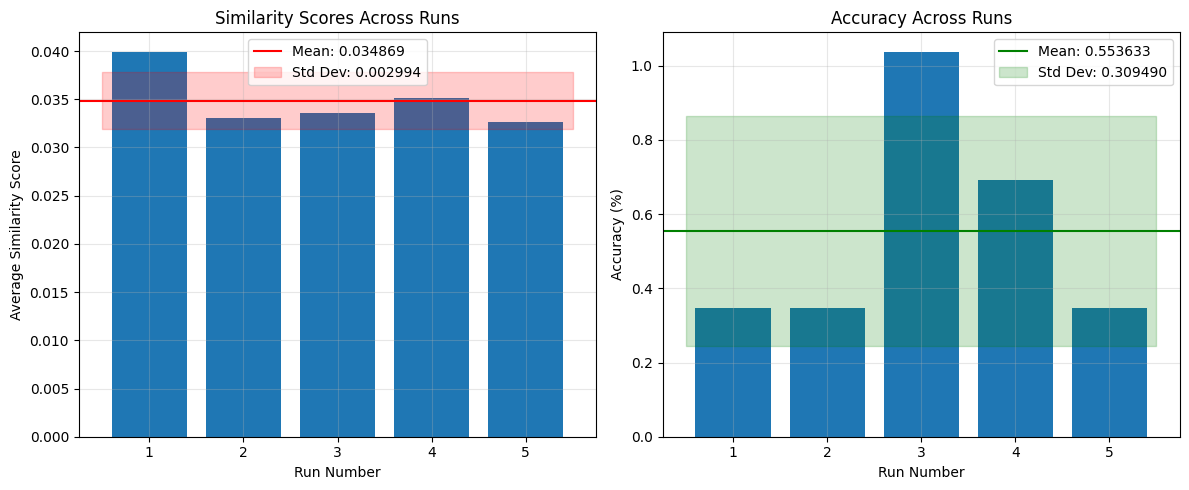

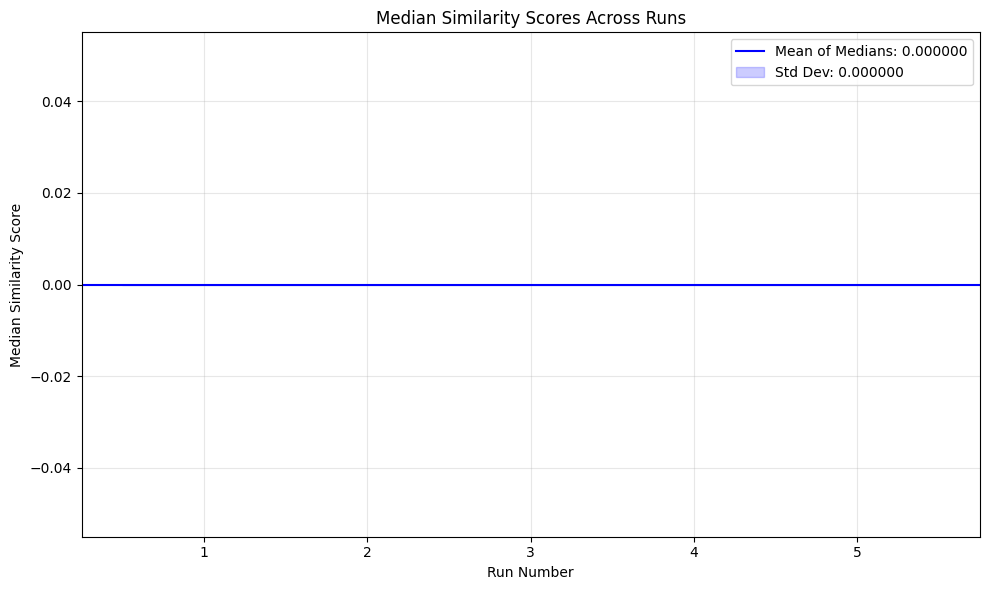

In [21]:
# Plot the similarity results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(metrics_df_tfidf['run'], metrics_df_tfidf['avg_similarity'])
plt.axhline(y=metrics_df_tfidf['avg_similarity'].mean(), color='r', linestyle='-',
            label=f'Mean: {metrics_df_tfidf["avg_similarity"].mean():.6f}')
plt.fill_between(
    [0.5, len(metrics_df_tfidf)+0.5],
    [metrics_df_tfidf['avg_similarity'].mean() - metrics_df_tfidf['avg_similarity'].std()]*2,
    [metrics_df_tfidf['avg_similarity'].mean() + metrics_df_tfidf['avg_similarity'].std()]*2,
    color='r', alpha=0.2, label=f'Std Dev: {metrics_df_tfidf["avg_similarity"].std():.6f}'
)
plt.xlabel('Run Number')
plt.ylabel('Average Similarity Score')
plt.title('Similarity Scores Across Runs')
plt.xticks(metrics_df_tfidf['run'])
plt.legend()
plt.grid(True, alpha=0.3)

# Plot the accuracy results
plt.subplot(1, 2, 2)
plt.bar(metrics_df_tfidf['run'], metrics_df_tfidf['pct_correct_matches'])
plt.axhline(y=metrics_df_tfidf['pct_correct_matches'].mean(), color='g', linestyle='-',
            label=f'Mean: {metrics_df_tfidf["pct_correct_matches"].mean():.6f}')
plt.fill_between(
    [0.5, len(metrics_df_tfidf)+0.5],
    [metrics_df_tfidf['pct_correct_matches'].mean() - metrics_df_tfidf['pct_correct_matches'].std()]*2,
    [metrics_df_tfidf['pct_correct_matches'].mean() + metrics_df_tfidf['pct_correct_matches'].std()]*2,
    color='g', alpha=0.2, label=f'Std Dev: {metrics_df_tfidf["pct_correct_matches"].std():.6f}'
)
plt.xlabel('Run Number')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Across Runs')
plt.xticks(metrics_df_tfidf['run'])
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Add a new plot for median similarity scores
plt.figure(figsize=(10, 6))
plt.bar(metrics_df_tfidf['run'], metrics_df_tfidf['median_similarity'])
plt.axhline(y=metrics_df_tfidf['median_similarity'].mean(), color='b', linestyle='-',
            label=f'Mean of Medians: {metrics_df_tfidf["median_similarity"].mean():.6f}')
plt.fill_between(
    [0.5, len(metrics_df_tfidf)+0.5],
    [metrics_df_tfidf['median_similarity'].mean() - metrics_df_tfidf['median_similarity'].std()]*2,
    [metrics_df_tfidf['median_similarity'].mean() + metrics_df_tfidf['median_similarity'].std()]*2,
    color='b', alpha=0.2, label=f'Std Dev: {metrics_df_tfidf["median_similarity"].std():.6f}'
)
plt.xlabel('Run Number')
plt.ylabel('Median Similarity Score')
plt.title('Median Similarity Scores Across Runs')
plt.xticks(metrics_df_tfidf['run'])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

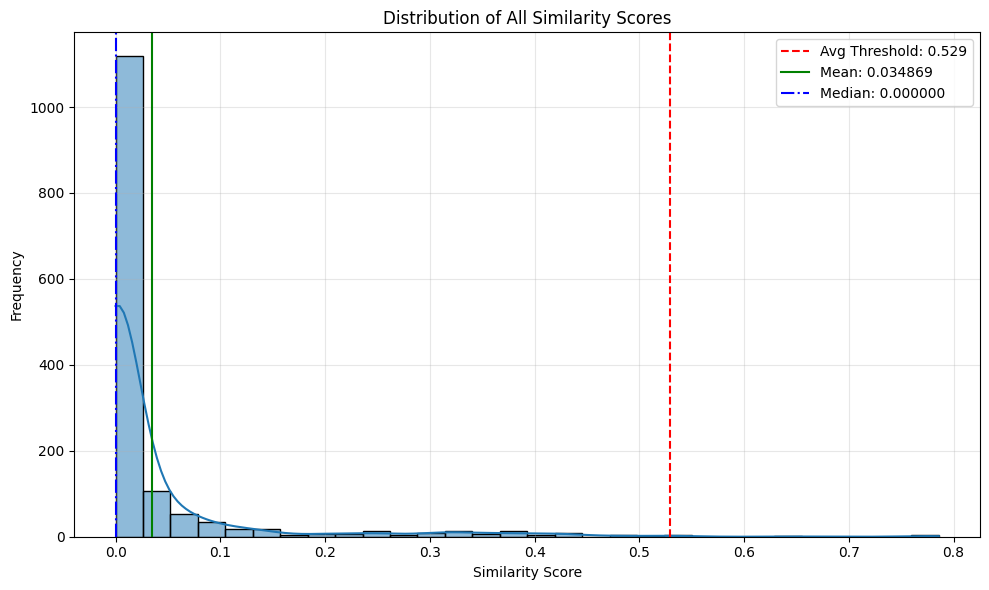

In [22]:
plt.figure(figsize=(10, 6))
sns.histplot(combined_df_tfidf['similarity_score'], bins=30, kde=True)

# Use the average threshold across runs
avg_threshold = metrics_df_tfidf['threshold_used'].mean()

plt.axvline(x=avg_threshold, color='r', linestyle='--', label=f'Avg Threshold: {avg_threshold:.3f}')
plt.axvline(x=metrics_df_tfidf['avg_similarity'].mean(), color='g', linestyle='-',
            label=f'Mean: {metrics_df_tfidf["avg_similarity"].mean():.6f}')
plt.axvline(x=metrics_df_tfidf['median_similarity'].mean(), color='b', linestyle='-.',
            label=f'Median: {metrics_df_tfidf["median_similarity"].mean():.6f}')

plt.xlabel('Similarity Score')
plt.ylabel('Frequency')
plt.title('Distribution of All Similarity Scores')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipython-input-1101821073.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=metrics_df_tfidf['run'])


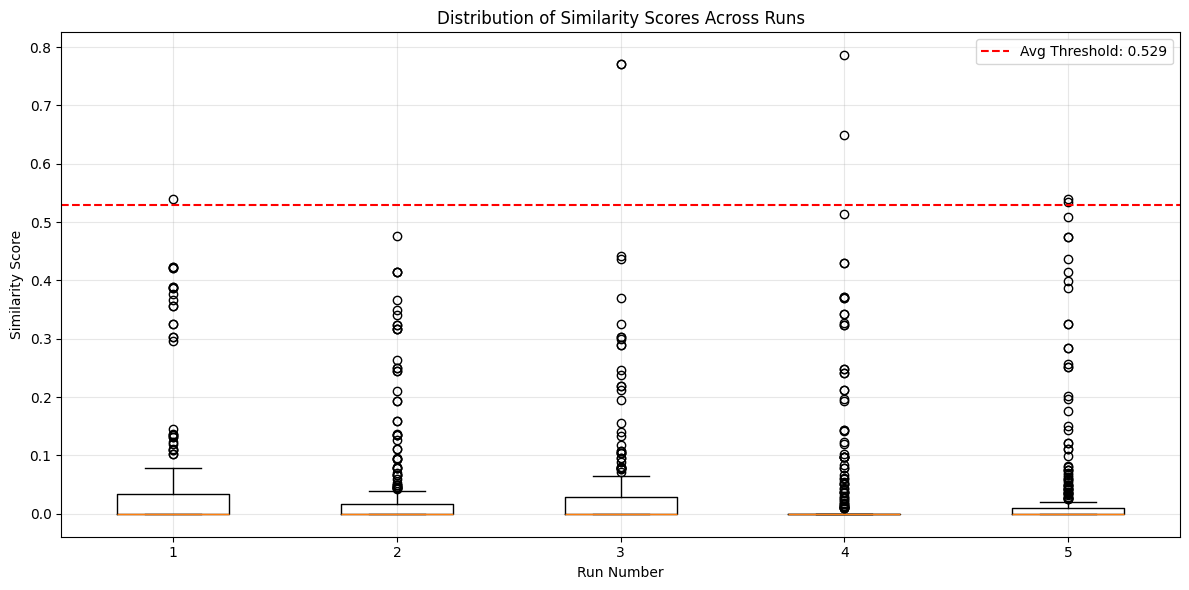

In [23]:
# 3. Box plot of similarity scores across runs
plt.figure(figsize=(12, 6))

# Create data for each run
boxplot_data = [
    combined_df_tfidf[combined_df_tfidf['run'] == run]['similarity_score']
    for run in metrics_df_tfidf['run']
]

# Draw boxplot
plt.boxplot(boxplot_data, labels=metrics_df_tfidf['run'])

# Use average threshold across runs
avg_threshold = metrics_df_tfidf['threshold_used'].mean()
plt.axhline(y=avg_threshold, color='r', linestyle='--', label=f'Avg Threshold: {avg_threshold:.3f}')

plt.xlabel('Run Number')
plt.ylabel('Similarity Score')
plt.title('Distribution of Similarity Scores Across Runs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

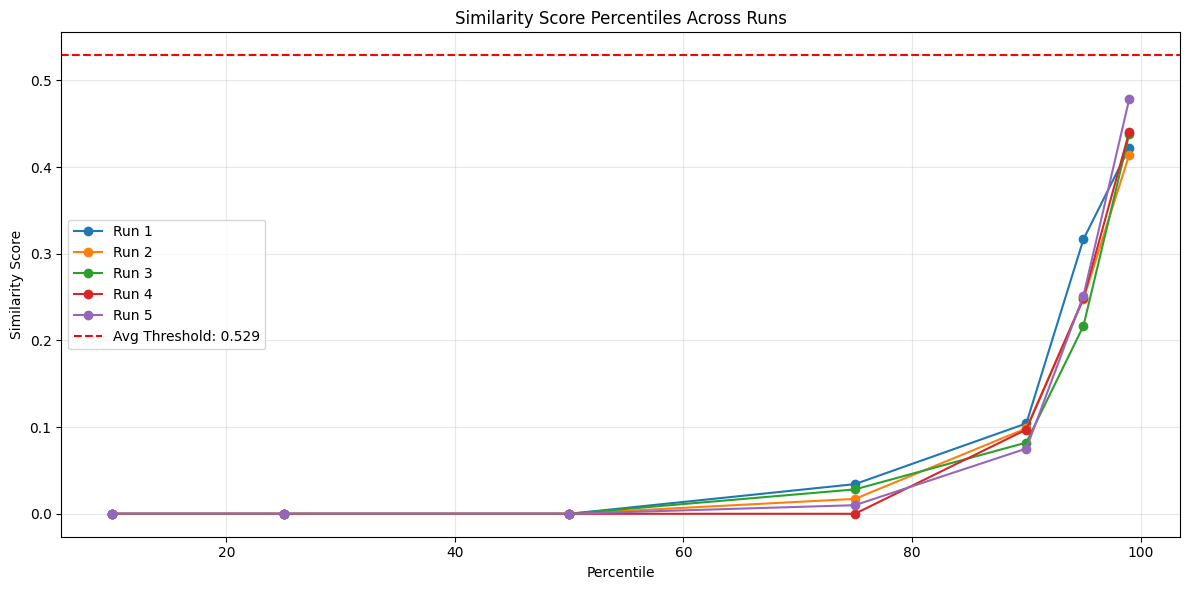

In [24]:
# 4. Percentile analysis
percentiles = [10, 25, 50, 75, 90, 95, 99]
plt.figure(figsize=(12, 6))

for run in metrics_df_tfidf['run']:
    run_data = combined_df_tfidf[combined_df_tfidf['run'] == run]['similarity_score']
    percentile_values = np.percentile(run_data, percentiles)
    plt.plot(percentiles, percentile_values, marker='o', label=f'Run {run}')

# Use average threshold across runs
avg_threshold = metrics_df_tfidf['threshold_used'].mean()
plt.axhline(y=avg_threshold, color='r', linestyle='--', label=f'Avg Threshold: {avg_threshold:.3f}')

plt.xlabel('Percentile')
plt.ylabel('Similarity Score')
plt.title('Similarity Score Percentiles Across Runs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

=== TF-IDF EVALUATION SUMMARY ===
Average similarity: 0.035 ± 0.003
Median similarity: 0.000
Std deviation: 0.093
Average adjusted accuracy: 0.006 ± 0.003
Average number of matches: 289.0
Average number of correct matches: 1.6
Average percentage of correct matches: 0.55%
Average adjusted threshold: 0.529



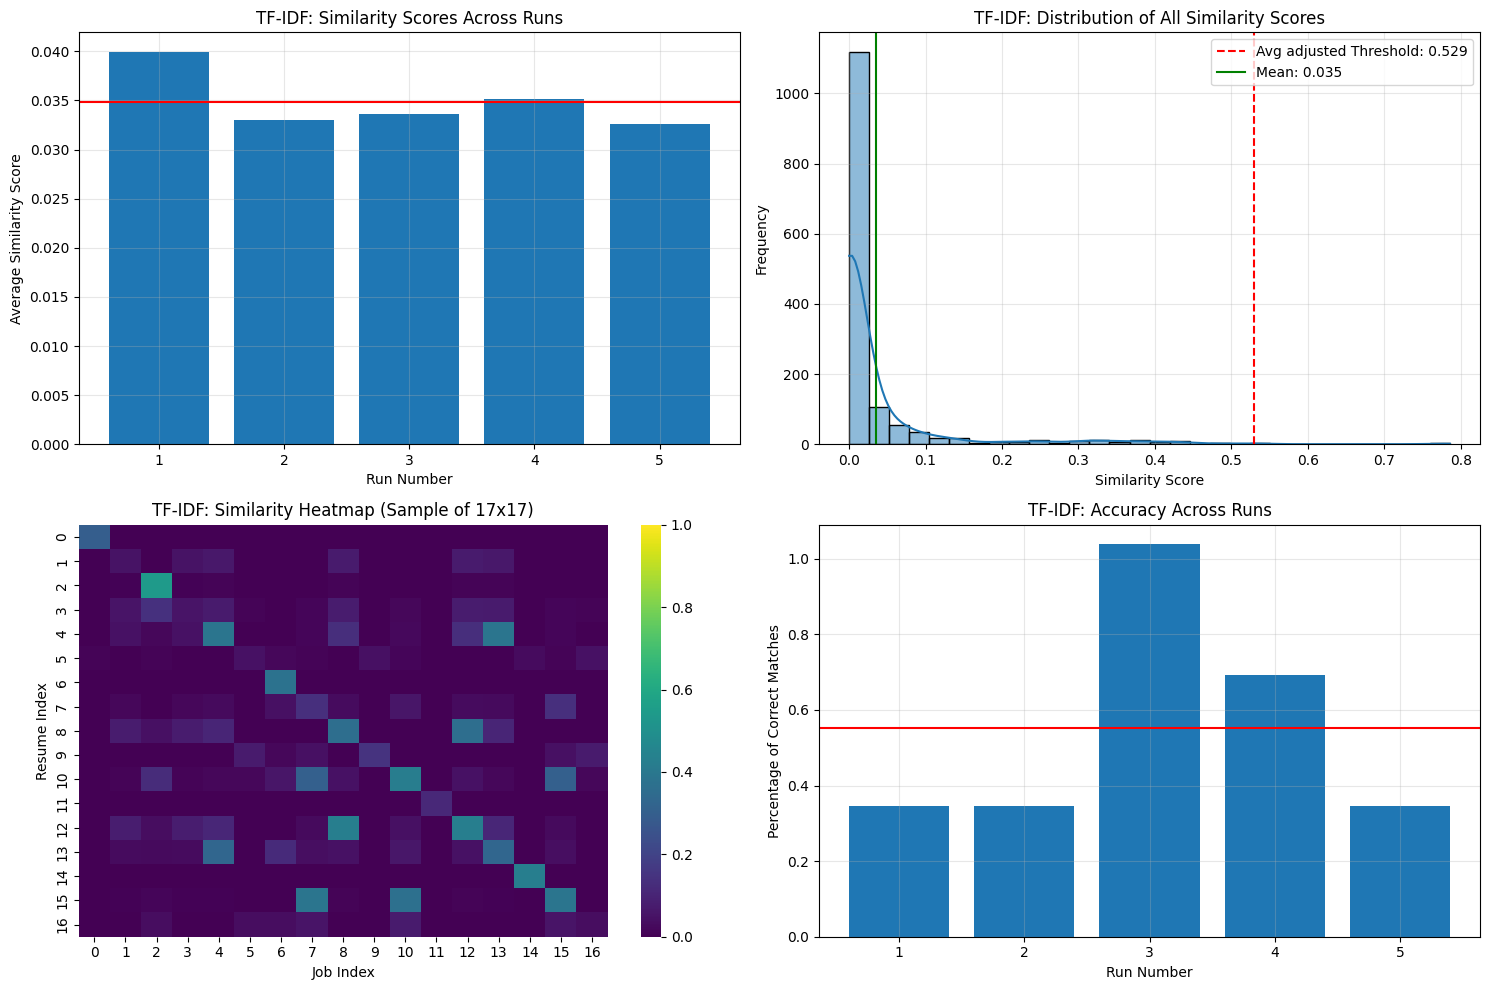


=== EXAMPLES OF HIGH SIMILARITY MATCHES ===

Similarity Score: 0.786
Resume (processed): education detail january 2005 ssc baramati maharashtra me highschool civil engineering pune maharash...
Resume (before preprocessing): Education Details 
January 2005 S.S.C  Baramati, Maharashtra M.E.S. Highschool
 B.E. Civil Enginee...
Job Category (annotated): Civil Engineer
Predicted Job category: Civil Engineer...
--------------------------------------------------

Similarity Score: 0.770
Resume (processed): education detail january 2005 ssc baramati maharashtra me highschool civil engineering pune maharash...
Resume (before preprocessing): Education Details 
January 2005 S.S.C  Baramati, Maharashtra M.E.S. Highschool
 B.E. Civil Enginee...
Job Category (annotated): Civil Engineer
Predicted Job category: Civil Engineer...
--------------------------------------------------

Similarity Score: 0.770
Resume (processed): education detail january 2005 ssc baramati maharashtra me highschool civil eng

In [25]:
# Print dynamic evaluation summary
# -------------------------------
print("=== TF-IDF EVALUATION SUMMARY ===")
print(f"Average similarity: {metrics_df_tfidf['avg_similarity'].mean():.3f} ± {metrics_df_tfidf['avg_similarity'].std():.3f}")
print(f"Median similarity: {metrics_df_tfidf['median_similarity'].mean():.3f}")
print(f"Std deviation: {metrics_df_tfidf['std_similarity'].mean():.3f}")
print(f"Average adjusted accuracy: {metrics_df_tfidf['accuracy'].mean():.3f} ± {metrics_df_tfidf['accuracy'].std():.3f}")
print(f"Average number of matches: {metrics_df_tfidf['num_matches'].mean():.1f}")
print(f"Average number of correct matches: {metrics_df_tfidf['num_correct_matches'].mean():.1f}")
print(f"Average percentage of correct matches: {metrics_df_tfidf['pct_correct_matches'].mean():.2f}%")
print(f"Average adjusted threshold: {metrics_df_tfidf['threshold_used'].mean():.3f}\n")


# =====================================
# TF-IDF VISUALIZATIONS (adapted version)
# =====================================

plt.figure(figsize=(15, 10))

# Plot 1: Average similarity across runs
plt.subplot(2, 2, 1)
plt.bar(metrics_df_tfidf['run'], metrics_df_tfidf['avg_similarity'])
plt.axhline(y=metrics_df_tfidf['avg_similarity'].mean(), color='r', linestyle='-')
plt.xlabel('Run Number')
plt.ylabel('Average Similarity Score')
plt.title('TF-IDF: Similarity Scores Across Runs')
plt.grid(True, alpha=0.3)

# Plot 2: Distribution of similarity scores
plt.subplot(2, 2, 2)
sns.histplot(combined_df_tfidf['similarity_score'], bins=30, kde=True)
similarity_threshold = metrics_df_tfidf['threshold_used'].mean()  # average threshold used
plt.axvline(x=similarity_threshold, color='r', linestyle='--', label=f'Avg adjusted Threshold: {similarity_threshold:.3f}')
plt.axvline(x=metrics_df_tfidf['avg_similarity'].mean(), color='g', linestyle='-',
            label=f'Mean: {metrics_df_tfidf["avg_similarity"].mean():.3f}')
plt.xlabel('Similarity Score')
plt.ylabel('Frequency')
plt.title('TF-IDF: Distribution of All Similarity Scores')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Heatmap of similarity scores (sample from run 1)
plt.subplot(2, 2, 3)
sample_size = min(50, combined_df_tfidf[combined_df_tfidf['run'] == 1]['resume_index'].nunique())
pivot_df = combined_df_tfidf[combined_df_tfidf['run'] == 1].iloc[:sample_size*sample_size]
pivot_matrix = pivot_df.pivot_table(
    index='resume_index',
    columns='job_index',
    values='similarity_score',
    aggfunc='mean'
).iloc[:sample_size, :sample_size]

sns.heatmap(pivot_matrix, cmap='viridis', vmin=0, vmax=1)
plt.title(f'TF-IDF: Similarity Heatmap (Sample of {sample_size}x{sample_size})')
plt.xlabel('Job Index')
plt.ylabel('Resume Index')

# Plot 4: Accuracy across runs
plt.subplot(2, 2, 4)
plt.bar(metrics_df_tfidf['run'], metrics_df_tfidf['pct_correct_matches'])
plt.axhline(y=metrics_df_tfidf['pct_correct_matches'].mean(), color='r', linestyle='-')
plt.xlabel('Run Number')
plt.ylabel('Percentage of Correct Matches')
plt.title('TF-IDF: Accuracy Across Runs')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ================================
# Show examples of matches
# ================================
print("\n=== EXAMPLES OF HIGH SIMILARITY MATCHES ===")
high_sim = combined_df_tfidf.sort_values('similarity_score', ascending=False).head(3)
for _, row in high_sim.iterrows():
    print(f"\nSimilarity Score: {row['similarity_score']:.3f}")
    print(f"Resume (processed): {row['resume_summary'][:100]}...")
    print(f"Resume (before preprocessing): {row['resume_original'][:100]}...")
    print(f"Job Category (annotated): {row['category_original']}")
    print(f"Predicted Job category: {row['job_summary'][:100]}...")
    print("-" * 50)

print("\n=== EXAMPLES OF LOW SIMILARITY MATCHES ===")
low_sim = combined_df_tfidf.sort_values('similarity_score').head(3)
for _, row in low_sim.iterrows():
    print(f"\nSimilarity Score: {row['similarity_score']:.3f}")
    print(f"Resume (processed): {row['resume_summary'][:100]}...")
    print(f"Resume (before preprocessing): {row['resume_original'][:100]}...")
    print(f"Job Category (annotated): {row['category_original']}")
    print(f"Predicted Job category: {row['job_summary'][:100]}...")
    print("-" * 50)


# ================================
# Percentile analysis
# ================================
percentiles = [10, 25, 50, 75, 90, 95, 99]
score_percentiles = np.percentile(combined_df_tfidf['similarity_score'], percentiles)

print("\n=== TF-IDF SIMILARITY SCORE PERCENTILES ===")
for p, score in zip(percentiles, score_percentiles):
    print(f"{p}th percentile: {score:.3f}")


# ================================
# Save results
# ================================
combined_df_tfidf.to_csv('tfidf_all_similarity_scores.csv', index=False)
metrics_df_tfidf.to_csv('tfidf_evaluation_metrics.csv', index=False)

print("\n=== TF-IDF EVALUATION COMPLETE ===")
print(f"Total matches evaluated: {len(combined_df_tfidf)}")
print(f"Results saved to CSV files")


=== TF-IDF SIMILARITY SCORES OF WRONG PREDICTIONS ===
count    1437.000000
mean        0.031603
std         0.082226
min         0.000000
25%         0.000000
50%         0.000000
75%         0.017188
max         0.534129
Name: similarity_score, dtype: float64
Lowest wrong score: 0.000
Highest wrong score: 0.534


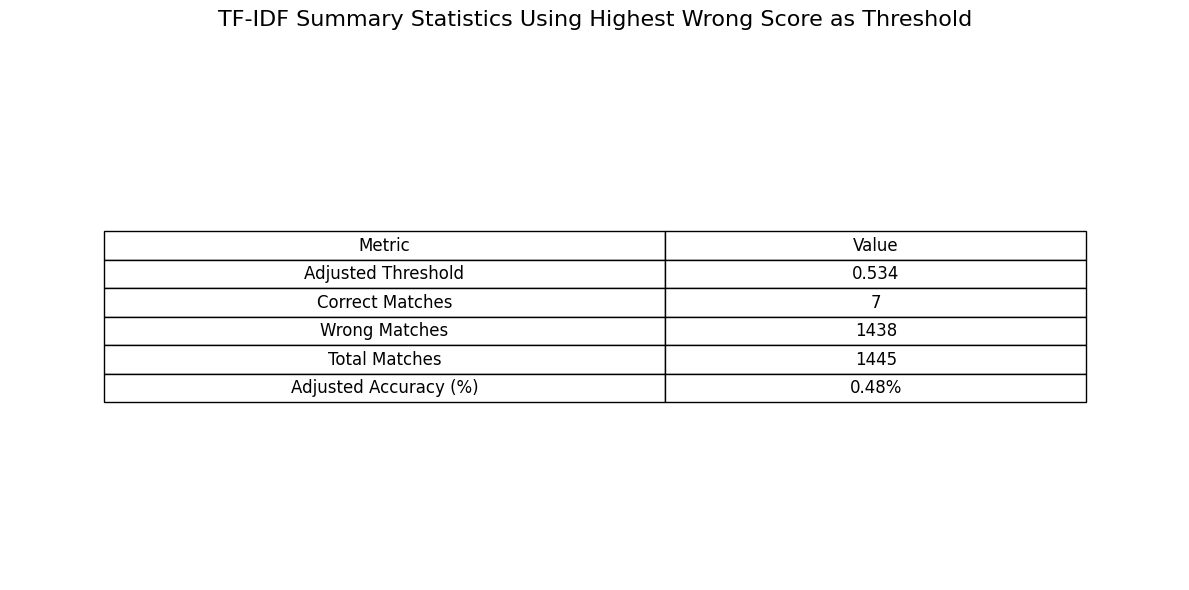

In [ ]:
# =====================================
# Extract wrong predictions for TF-IDF
# =====================================
wrong_preds_tfidf = combined_df_tfidf[combined_df_tfidf['is_correct'] == False]

# Check the distribution of their similarity scores
print("\n=== TF-IDF SIMILARITY SCORES OF WRONG PREDICTIONS ===")
print(wrong_preds_tfidf['similarity_score'].describe())

# Lowest and highest scores among wrong predictions
lowest_wrong_score = wrong_preds_tfidf['similarity_score'].min()
highest_wrong_score = wrong_preds_tfidf['similarity_score'].max()

print(f"Lowest wrong score: {lowest_wrong_score:.3f}")
print(f"Highest wrong score: {highest_wrong_score:.3f}")

# Optional: set adjusted threshold to highest wrong score
adjusted_threshold_tfidf = highest_wrong_score
combined_df_tfidf['is_correct_adjusted'] = combined_df_tfidf['similarity_score'] >= adjusted_threshold_tfidf

# Count correct and wrong matches based on adjusted threshold
num_correct_tfidf = combined_df_tfidf['is_correct_adjusted'].sum()
num_wrong_tfidf = len(combined_df_tfidf) - num_correct_tfidf
accuracy_adjusted_tfidf = num_correct_tfidf / len(combined_df_tfidf) * 100

# Display summary table
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.axis('off')
table_data = [
    ['Metric', 'Value'],
    ['Adjusted Threshold', f"{adjusted_threshold_tfidf:.3f}"],
    ['Correct Matches', f"{num_correct_tfidf}"],
    ['Wrong Matches', f"{num_wrong_tfidf}"],
    ['Total Matches', f"{len(combined_df_tfidf)}"],
    ['Adjusted Accuracy (%)', f"{accuracy_adjusted_tfidf:.2f}%"]
]

table = plt.table(cellText=table_data, cellLoc='center', loc='center', colWidths=[0.4, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.5)
plt.title('TF-IDF Summary Statistics Using Highest Wrong Score as Threshold', fontsize=16, pad=20)
plt.tight_layout()
plt.show()
